<h1> Part 1: Blob Detection with OpenCV </h1>
In this section we will use OpenCV's SimpleBlobDetector class to detect blobs in an image. Run the cell below to import libraries: 

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

#Some helper functions that will be useful later
def draw_keypoints_on_image(keypoints, image):
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])  # center
        r = int(kp.size / 2)  # radius
        cv2.circle(image, (x, y), r, (0, 255, 0), thickness=3)
    return image

First, lets load the image and see what they look like:

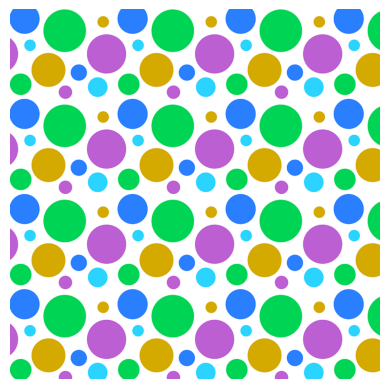

In [3]:
FILE_1 = "example_images/polka_dots_1.png"
original_image_1 = cv2.imread(FILE_1)

plt.imshow(original_image_1)
plt.axis("off")
plt.show()

Now, we can grayscale the image and simply call the SimpleBlobDetector constructor to detect blobs

[ WARN:0@1434.849] global blobdetector.cpp:389 detect SimpleBlobDetector: params.minRepeatability=2 is incompatible for case with single threshold. Empty result is expected.


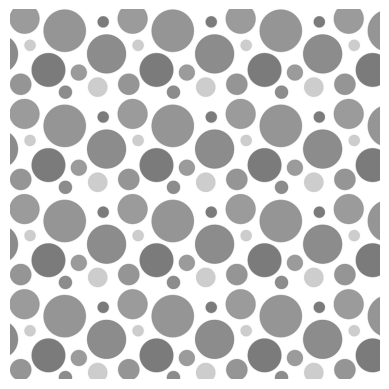

In [22]:
image = cv2.imread(FILE_1, cv2.IMREAD_GRAYSCALE)

params = cv2.SimpleBlobDetector_Params()

# Parameters
params.minThreshold = 1   
params.maxThreshold = 10   
params.filterByArea = False
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False
params.filterByColor = False

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(image)

# Convert grayscale image to color for drawing
output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

output = draw_keypoints_on_image(keypoints, output)
plt.imshow(output)
plt.axis("off")
plt.show()


Wait, what's going on here? Why are none of the polka dots circled? \
We need to set better parameters in order for OpenCV to detect the blobs! Check out the OpenCV reference to see what parameters you can change(https://docs.opencv.org/3.4/d8/da7/structcv_1_1SimpleBlobDetector_1_1Params.html)



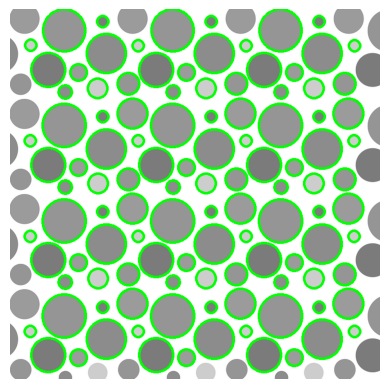

In [17]:
#TODO: edit/add parameters so blobs are circled
params.minThreshold = 200
params.maxThreshold = 255
params.filterByArea = False
params.filterByCircularity = True
params.filterByConvexity = False
params.filterByInertia = False
params.filterByColor = False

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(image)

#Convert grayscale image to color for drawing
output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

output = draw_keypoints_on_image(keypoints, output)
plt.imshow(output)
plt.axis("off")
plt.show()

Congrats! You now have a simple blob detector ready for use. Feel free to try this blob detector on other images to see what happens!

<h1> (Optional) Part 2: Create your own blob detection system! </h1>

Using LoG or your own method, design a system to detect objects on a uniform background


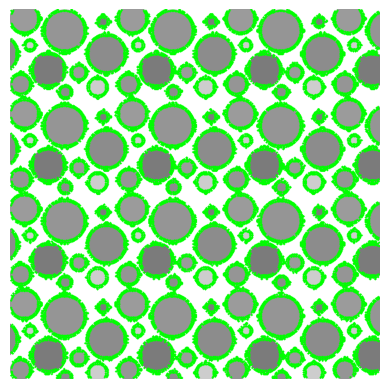

In [23]:
# LoG method implementation
def get_keypoints(image):
    LoG_kernel = np.array([
        [0, -1, 0],
        [-1, 4, -1],
        [0, -1, 0]
    ])

    Gaussian_kernel = np.array([
        [1/16, 1/8, 1/16],
        [1/8, 1/4, 1/8],
        [1/16, 1/8, 1/16]
    ])

    blurred = cv2.filter2D(image, -1, Gaussian_kernel)
    filtered_image = cv2.filter2D(blurred, -1, LoG_kernel)

    # Normalize the response
    response = np.abs(filtered_image)
    response = response / np.max(response)
    
    keypoints = []

    # Find local maxima
    for row in range(1, response.shape[0]-1):
        for col in range(1, response.shape[1]-1):
            neighborhood = response[row-1:row+2, col-1:col+2]
            target = response[row, col]

            if target == np.max(neighborhood) and target > 0.01:
                keypoints.append(cv2.KeyPoint(col, row, 1))
    
    return np.array(keypoints)

keypoints = get_keypoints(image)
output = draw_keypoints_on_image(keypoints, output)
plt.imshow(output)
plt.axis("off")
plt.show()